In [1]:
import os
import diopy
import numpy as np
import pandas as pd
import scanpy as sc 
import anndata as ad
import scanpy.external as sce
import matplotlib.pyplot as plt
import cosg


In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')
# maximum number of columns
pd.options.display.max_columns = None
pd.options.display.max_rows = None

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.3 anndata==0.9.1 umap==0.5.3 numpy==1.22.4 scipy==1.10.1 pandas==2.0.2 scikit-learn==1.2.2 statsmodels==0.14.0 python-igraph==0.10.4 pynndescent==0.5.10


In [3]:
adata = diopy.input.read_h5(file = '/bigdata/zlin/Melanoma_meta/data/BRCA_Bassez2/seu.h5')
adata.X = adata.layers['counts'].copy()
adata

AnnData object with n_obs × n_vars = 49259 × 22775
    obs: 'patient', 'time_point', 'response', 'subtype', 'cellType', 'cohort', 'sample', 'treatment', 'dataset', 'platform', 'site', 'batch', 'nCount_RNA', 'nFeature_RNA', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'celltype_bped_main', 'celltype_bped_fine', 'immune', 'celltype_major', 'cell_keep'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    layers: 'counts'

In [4]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
# filter genes
sc.pp.filter_genes(adata, min_cells=20)

filtered out 3326 genes that are detected in less than 20 cells


In [5]:
# retain adata with counts as .X
adata_counts = adata.copy()

In [6]:
noise = pd.read_excel("/bigdata/zlin/Melanoma_meta/data/41586_2022_5400_MOESM3_ESM.xlsx", sheet_name="1d_Genes excluded", index_col=0, header = 2)
noise = noise.to_numpy().flatten()
noise = noise[~pd.isnull(noise)]
noise = np.append(noise, "MALAT1")

In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata

normalizing counts per cell


    finished (0:00:00)


In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, layer='counts', flavor='seurat_v3', subset=True)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [9]:
adata = adata[:,np.setdiff1d(adata.var_names.values, noise)]
adata

View of AnnData object with n_obs × n_vars = 49259 × 1980
    obs: 'patient', 'time_point', 'response', 'subtype', 'cellType', 'cohort', 'sample', 'treatment', 'dataset', 'platform', 'site', 'batch', 'nCount_RNA', 'nFeature_RNA', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'celltype_bped_main', 'celltype_bped_fine', 'immune', 'celltype_major', 'cell_keep', 'n_genes_by_counts', 'total_counts'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [16]:
# sc.pp.regress_out(adata, ['total_counts','S.Score','G2M.Score'])
# sc.pp.scale(adata, max_value=10)
# sc.pp.pca(adata, svd_solver='arpack')
sce.pp.bbknn(adata, batch_key='sample')
# sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
	`.obsp['distances']`, distances for each pair of neighbors
	`.obsp['connectivities']`, weighted adjacency matrix (0:00:23)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:56)
running Leiden clustering
    finished: found 14 clusters and added
    'leiden_0.5', the cluster labels (adata.obs, categorical) (0:00:26)


In [18]:
sc.tl.leiden(adata, resolution=1, key_added='leiden_1')

running Leiden clustering
    finished: found 21 clusters and added
    'leiden_1', the cluster labels (adata.obs, categorical) (0:00:28)


/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


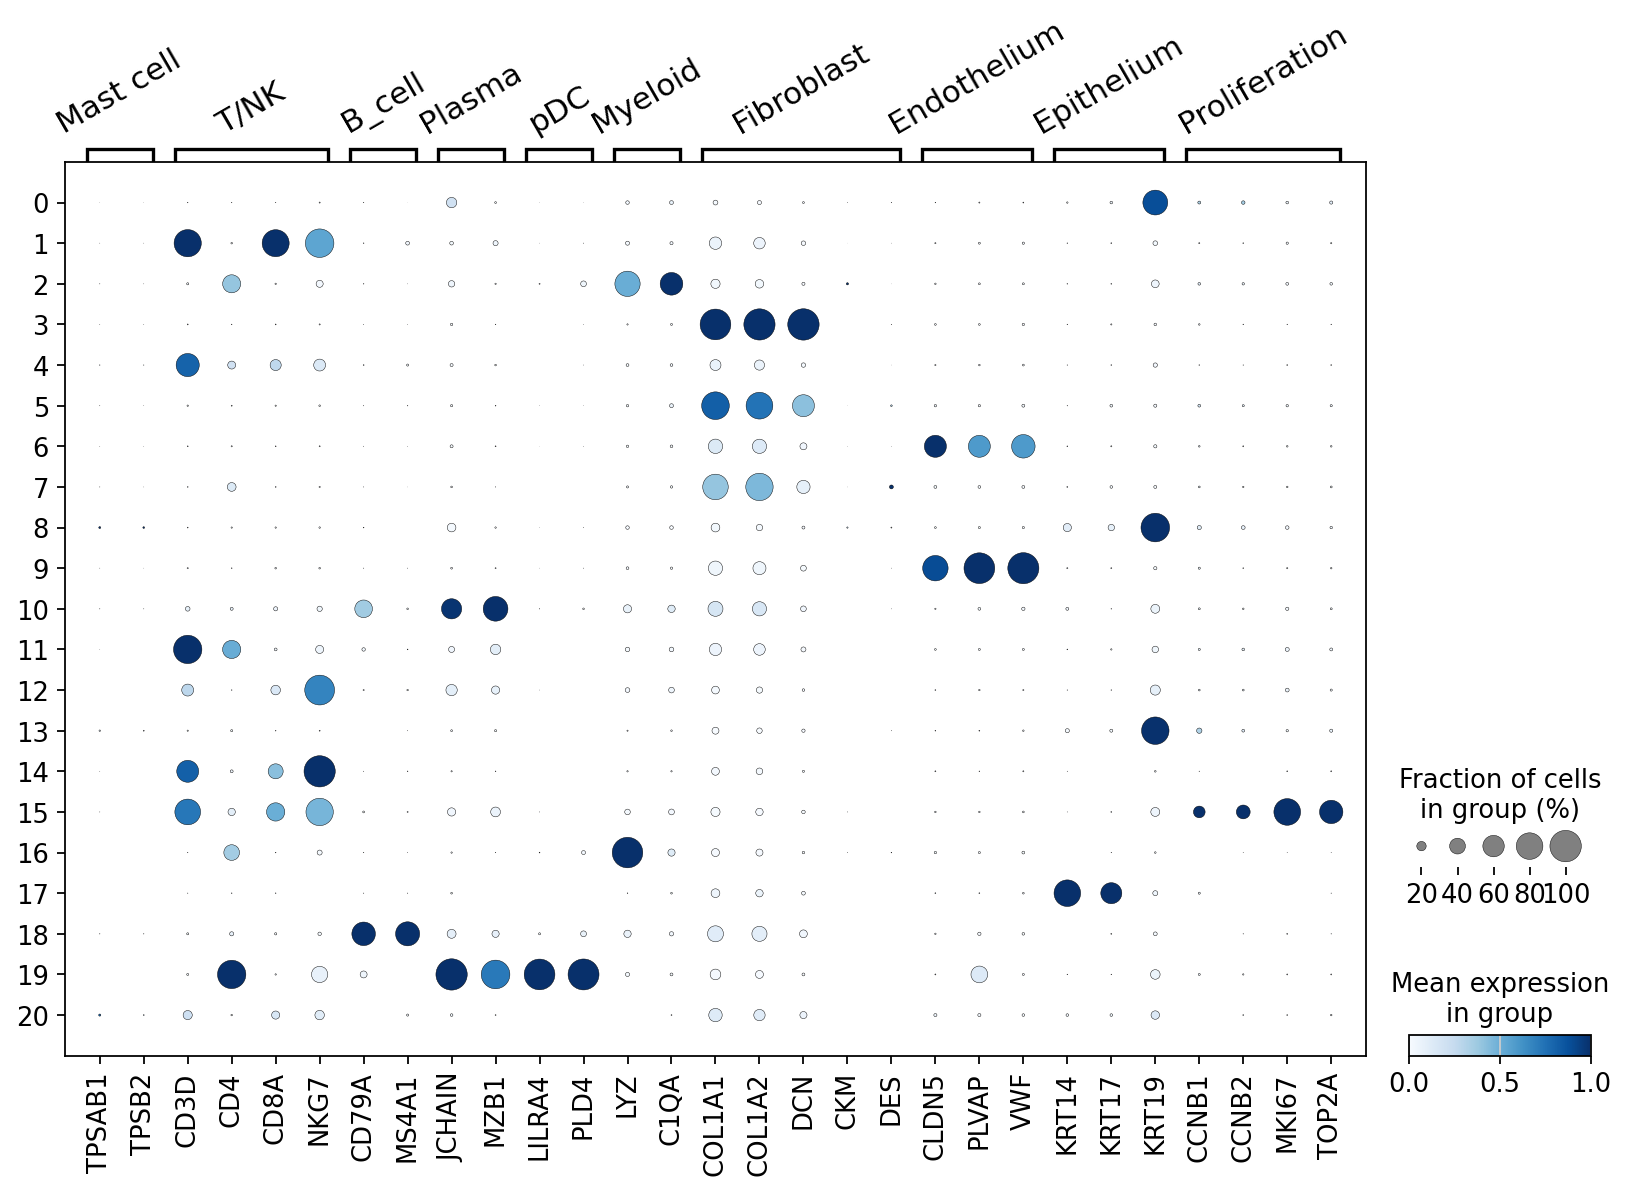

In [19]:
# check markers
marker_genes_dict = {
    'Mast cell':['TPSAB1','TPSB2'],
    'T/NK': ['CD3D','CD4','CD8A','NKG7'],
    'B_cell':['CD79A','MS4A1'],
    'Plasma':['JCHAIN','MZB1'],
    'pDC':['LILRA4','PLD4'],
    'Myeloid':['LYZ','C1QA'],
    'Fibroblast':['COL1A1','COL1A2','DCN','CKM','DES'],
    'Endothelium':['CLDN5','PLVAP','VWF'],
    'Epithelium':['KRT14','KRT17','KRT19'],
    'Proliferation': ['CCNB1','CCNB2','MKI67','TOP2A']
}
sc.pl.dotplot(adata, marker_genes_dict, 'leiden_1' ,cmap='Blues', var_group_rotation=30, standard_scale='var')

In [20]:
adata.obs['celltype_major'] = adata.obs['celltype_major'].astype(str)
adata.obs.loc[adata.obs['celltype_major'].isin(['B_cells']) & adata.obs['leiden_1'].isin(['10']), 'celltype_major'] = 'Plasma'

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


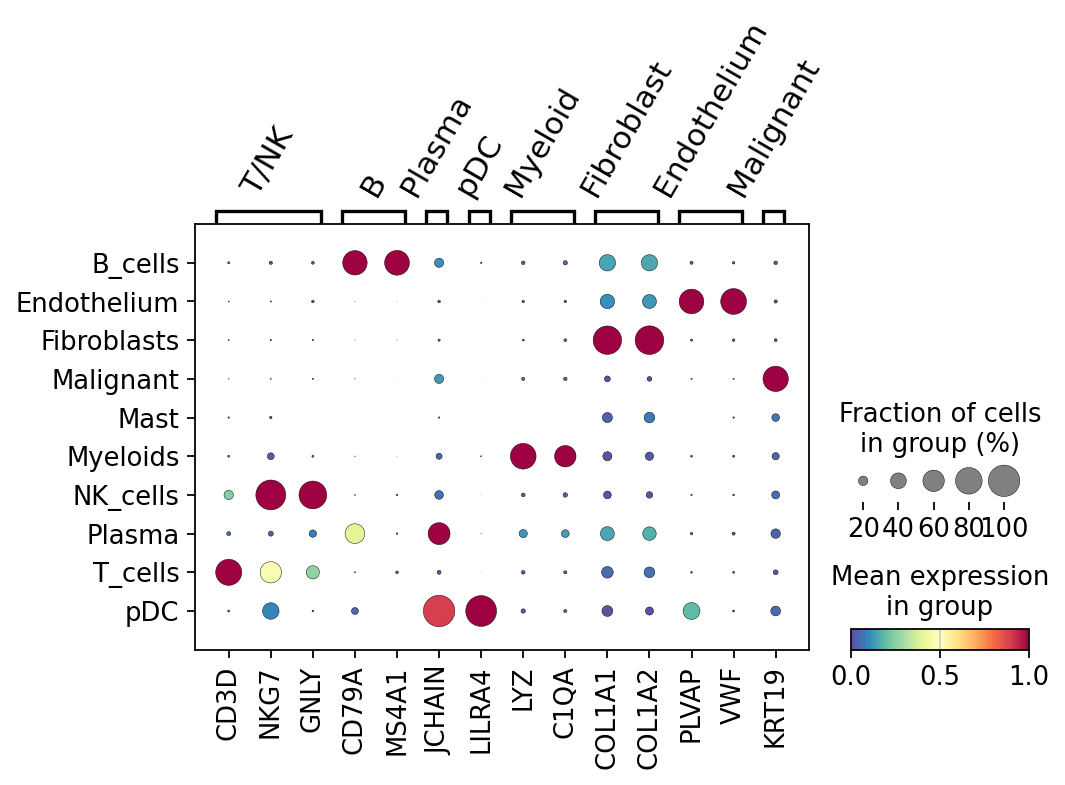

In [21]:
marker_genes_dict = {
    'T/NK': ['CD3D','NKG7','GNLY'],
    'B':['CD79A','MS4A1'],
    'Plasma':['JCHAIN'],
    'pDC':['LILRA4'],
    'Myeloid':['LYZ','C1QA'],
    'Fibroblast':['COL1A1','COL1A2'],
    'Endothelium':['PLVAP','VWF'],
    'Malignant':['KRT19']
}
sc.pl.dotplot(adata, marker_genes_dict,'celltype_major',cmap='Spectral_r', var_group_rotation=60, standard_scale='var')

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


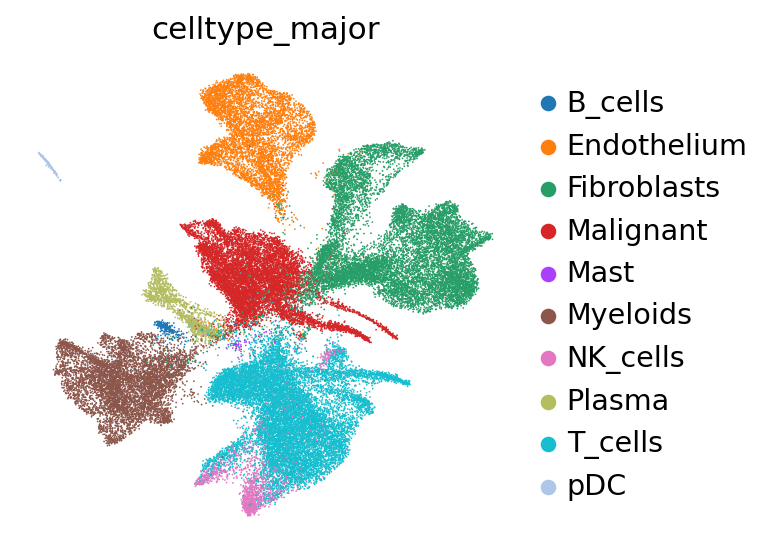

In [22]:
sc.pl.umap(adata, color=['celltype_major'],frameon=False)

In [23]:
adata_counts.obs['celltype_major'] = adata.obs['celltype_major']

In [24]:
# save object
diopy.output.write_h5(adata_counts, file = '/bigdata/zlin/Melanoma_meta/data/BRCA_Bassez2/annotated.h5')